### 1: Imports


In [2]:
import sys
%pip install torch h5py numpy scipy matplotlib scikit-learn seaborn

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   -- ------------------------------------- 9.2/123.0 MB 51.8 MB/s eta 0:00:03
   ------ --------------------------------- 19.9/123.0 MB 50.3 MB/s eta 0:00:03
   ---------- ----------------------------- 30.9/123.0 MB 50.3 MB/s eta 0:00:02
   ------------- -------------------------- 40.9/123.0 MB 49.1 MB/s eta 0:00:02
   ---------------- ----------------------- 50.3/123.0 MB 48.5 MB/s eta 0:00:02
   ------------------- -------------------- 59.8/123.0 MB 47.6 MB/s eta 0:00:02
   ---------------------- ----------------- 70.5/123.0 MB 47.8 MB/s eta 0:00:02
   -------------------------- ------------- 81.3/123.0 MB 48.4 MB/s eta 0:00:01
   ----------------------------- ---------- 92.0/123.0 MB 48.5 MB/s eta 0:00:01
   -------------------------------- ------ 102.5/123.0 MB 48.8 MB/s eta 0:00:01
   ----------------------------------- --- 113.5/123.0 MB 49.0 MB/s 

In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from scipy.signal import decimate
from scipy.stats import zscore
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

### 2: Settings

In [12]:

DATA_ROOT = r"C:\Users\ilayd\OneDrive\Documenten\MSc Deep learning\Final Project data"

INTRA_PATH = os.path.join(DATA_ROOT, "Intra")
CROSS_PATH = os.path.join(DATA_ROOT, "Cross")

CLASS_NAMES = ["Rest", "Motor", "Working Memory", "Story/Math"]

DOWNSAMPLE_FACTOR = 20
WINDOW_SIZE = 200
STEP_SIZE = 200

BATCH_SIZE = 32
EPOCHS = 30 
LEARNING_RATE = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


### 3: Preprocessing

In [13]:
def get_label(filename):
    filename = filename.lower()

    if "rest" in filename:
        return 0
    if "motor" in filename:
        return 1
    if "working_memory" in filename:
        return 2
    if "story" in filename or "math" in filename:
        return 3

    return -1


def load_h5_file(file_path):
    with h5py.File(file_path, "r") as f:
        key = list(f.keys())[0]
        data = f[key][:]
    return data


def preprocess(data):
    data = decimate(data, DOWNSAMPLE_FACTOR, axis=1)
    data = zscore(data, axis=1)
    data = np.nan_to_num(data)
    return data.astype(np.float32)


def make_windows(data):
    windows = []

    for start in range(0, data.shape[1] - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE
        windows.append(data[:, start:end])

    return np.array(windows, dtype=np.float32)


def load_folder(folder_path):
    X = []
    y = []

    files = sorted([f for f in os.listdir(folder_path) if f.endswith(".h5")])

    for filename in files:
        label = get_label(filename)

        if label == -1:
            continue

        file_path = os.path.join(folder_path, filename)

        data = load_h5_file(file_path)
        data = preprocess(data)
        windows = make_windows(data)

        X.append(windows)
        y.extend([label] * len(windows))

    X = np.concatenate(X, axis=0)
    y = np.array(y)

    return X, y

### 4: Loading data

In [14]:
X_intra_train, y_intra_train = load_folder(os.path.join(INTRA_PATH, "train"))
X_intra_test, y_intra_test = load_folder(os.path.join(INTRA_PATH, "test"))

X_cross_train, y_cross_train = load_folder(os.path.join(CROSS_PATH, "train"))

X_cross_test1, y_cross_test1 = load_folder(os.path.join(CROSS_PATH, "test1"))
X_cross_test2, y_cross_test2 = load_folder(os.path.join(CROSS_PATH, "test2"))
X_cross_test3, y_cross_test3 = load_folder(os.path.join(CROSS_PATH, "test3"))

X_cross_test = np.concatenate([X_cross_test1, X_cross_test2, X_cross_test3], axis=0)
y_cross_test = np.concatenate([y_cross_test1, y_cross_test2, y_cross_test3], axis=0)

print("Intra train:", X_intra_train.shape, y_intra_train.shape)
print("Intra test:", X_intra_test.shape, y_intra_test.shape)
print("Cross train:", X_cross_train.shape, y_cross_train.shape)
print("Cross test:", X_cross_test.shape, y_cross_test.shape)

Intra train: (256, 248, 200) (256,)
Intra test: (64, 248, 200) (64,)
Cross train: (512, 248, 200) (512,)
Cross test: (384, 248, 200) (384,)


In [15]:
def make_loader(X, y, shuffle=True):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)

    return loader

## 5: CNN + LSTM model

In [18]:
class CNNLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=248, out_channels=64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Dropout(0.5),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=64,
            batch_first=True,
            bidirectional=True,
        )

        self.classifier = nn.Linear(128, 4)

    def forward(self, x):
        # Input shape: batch, channels, time
        x = self.cnn(x)

        # LSTM expects: batch, time, features
        x = x.permute(0, 2, 1)

        lstm_output, _ = self.lstm(x)
        last_time_step = lstm_output[:, -1, :]

        logits = self.classifier(last_time_step)
        return logits

### 6: Training + evaluation

In [7]:
def train_model(model, train_loader, val_loader):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_acc_history = []
    val_acc_history = []

    for epoch in range(EPOCHS):
        model.train()

        train_predictions = []
        train_labels = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            predictions = torch.argmax(logits, dim=1)

            train_predictions.extend(predictions.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_predictions)
        val_acc = evaluate_accuracy(model, val_loader)

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train acc: {train_acc:.4f} | "
            f"Val acc: {val_acc:.4f}"
        )

    return train_acc_history, val_acc_history


def evaluate_accuracy(model, loader):
    model.eval()

    predictions_all = []
    labels_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            predictions = torch.argmax(logits, dim=1)

            predictions_all.extend(predictions.cpu().numpy())
            labels_all.extend(y_batch.numpy())

    return accuracy_score(labels_all, predictions_all)


def get_predictions(model, loader):
    model.eval()

    predictions_all = []
    labels_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            predictions = torch.argmax(logits, dim=1)

            predictions_all.extend(predictions.cpu().numpy())
            labels_all.extend(y_batch.numpy())

    return np.array(labels_all), np.array(predictions_all)

### 7: Plot functions

In [19]:
def plot_accuracy(train_acc, val_acc, title):
    plt.figure(figsize=(7, 4))
    plt.plot(train_acc, label="Train accuracy")
    plt.plot(val_acc, label="Validation accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(4), CLASS_NAMES, rotation=45)
    plt.yticks(range(4), CLASS_NAMES)

    for i in range(4):
        for j in range(4):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

### 8: Intra-subject experiment

Epoch 1/30 | Train acc: 0.2656 | Val acc: 0.3750
Epoch 2/30 | Train acc: 0.4531 | Val acc: 0.4375
Epoch 3/30 | Train acc: 0.5352 | Val acc: 0.4844
Epoch 4/30 | Train acc: 0.6367 | Val acc: 0.5312
Epoch 5/30 | Train acc: 0.6562 | Val acc: 0.4844
Epoch 6/30 | Train acc: 0.6836 | Val acc: 0.4375
Epoch 7/30 | Train acc: 0.6758 | Val acc: 0.4688
Epoch 8/30 | Train acc: 0.7695 | Val acc: 0.4688
Epoch 9/30 | Train acc: 0.7383 | Val acc: 0.5469
Epoch 10/30 | Train acc: 0.8242 | Val acc: 0.5000
Epoch 11/30 | Train acc: 0.8164 | Val acc: 0.4844
Epoch 12/30 | Train acc: 0.8750 | Val acc: 0.5156
Epoch 13/30 | Train acc: 0.8594 | Val acc: 0.4844
Epoch 14/30 | Train acc: 0.9336 | Val acc: 0.5625
Epoch 15/30 | Train acc: 0.8867 | Val acc: 0.4844
Epoch 16/30 | Train acc: 0.9531 | Val acc: 0.4688
Epoch 17/30 | Train acc: 0.9609 | Val acc: 0.4844
Epoch 18/30 | Train acc: 0.9453 | Val acc: 0.5625
Epoch 19/30 | Train acc: 0.9609 | Val acc: 0.5312
Epoch 20/30 | Train acc: 0.9766 | Val acc: 0.5312
Epoch 21/

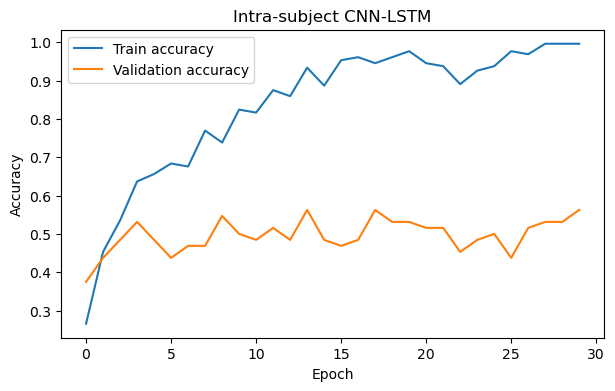

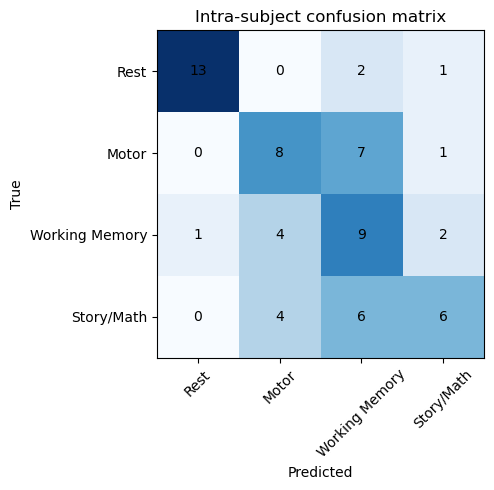

In [20]:

intra_train_loader = make_loader(X_intra_train, y_intra_train, shuffle=True)
intra_test_loader = make_loader(X_intra_test, y_intra_test, shuffle=False)

intra_model = CNNLSTM()

intra_train_acc, intra_val_acc = train_model(
    intra_model,
    intra_train_loader,
    intra_test_loader,
)

y_true_intra, y_pred_intra = get_predictions(intra_model, intra_test_loader)
intra_accuracy = accuracy_score(y_true_intra, y_pred_intra)

print("Intra-subject accuracy:", intra_accuracy)
print(classification_report(y_true_intra, y_pred_intra, target_names=CLASS_NAMES))

plot_accuracy(intra_train_acc, intra_val_acc, "Intra-subject CNN-LSTM")
plot_confusion_matrix(y_true_intra, y_pred_intra, "Intra-subject confusion matrix")

### 9: Cross-subject experiment

Epoch 1/30 | Train acc: 0.2943 | Val acc: 0.3636
Epoch 2/30 | Train acc: 0.4598 | Val acc: 0.4156
Epoch 3/30 | Train acc: 0.5954 | Val acc: 0.4416
Epoch 4/30 | Train acc: 0.6437 | Val acc: 0.5455
Epoch 5/30 | Train acc: 0.6759 | Val acc: 0.4805
Epoch 6/30 | Train acc: 0.7218 | Val acc: 0.5584
Epoch 7/30 | Train acc: 0.7310 | Val acc: 0.5714
Epoch 8/30 | Train acc: 0.8046 | Val acc: 0.5455
Epoch 9/30 | Train acc: 0.7908 | Val acc: 0.6234
Epoch 10/30 | Train acc: 0.8460 | Val acc: 0.6104
Epoch 11/30 | Train acc: 0.8736 | Val acc: 0.6883
Epoch 12/30 | Train acc: 0.8414 | Val acc: 0.6623
Epoch 13/30 | Train acc: 0.8920 | Val acc: 0.6623
Epoch 14/30 | Train acc: 0.9287 | Val acc: 0.7013
Epoch 15/30 | Train acc: 0.9379 | Val acc: 0.5714
Epoch 16/30 | Train acc: 0.9241 | Val acc: 0.6623
Epoch 17/30 | Train acc: 0.9402 | Val acc: 0.6623
Epoch 18/30 | Train acc: 0.9586 | Val acc: 0.5974
Epoch 19/30 | Train acc: 0.9264 | Val acc: 0.6104
Epoch 20/30 | Train acc: 0.9333 | Val acc: 0.6494
Epoch 21/

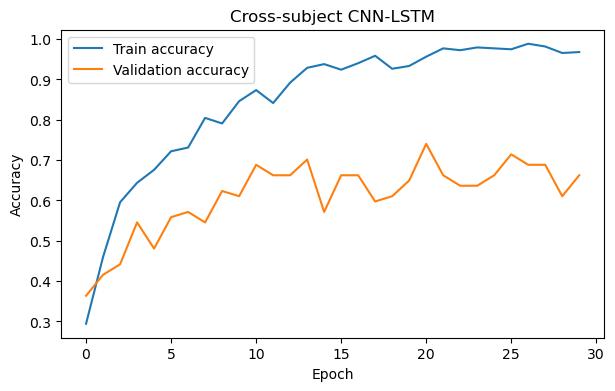

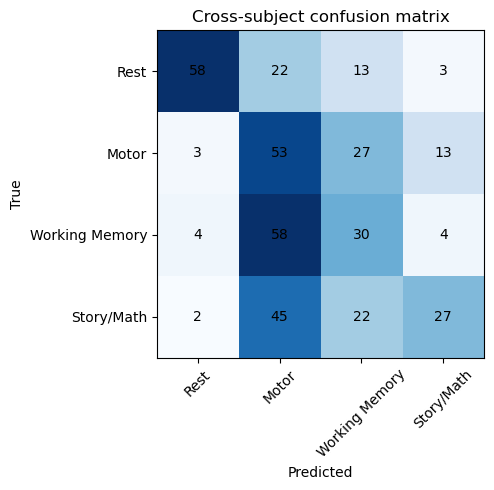

In [21]:
X_cross_train_part, X_cross_val, y_cross_train_part, y_cross_val = train_test_split(
    X_cross_train,
    y_cross_train,
    test_size=0.15,
    random_state=42,
    stratify=y_cross_train,
)

cross_train_loader = make_loader(X_cross_train_part, y_cross_train_part, shuffle=True)
cross_val_loader = make_loader(X_cross_val, y_cross_val, shuffle=False)
cross_test_loader = make_loader(X_cross_test, y_cross_test, shuffle=False)

cross_model = CNNLSTM()

cross_train_acc, cross_val_acc = train_model(
    cross_model,
    cross_train_loader,
    cross_val_loader,
)

y_true_cross, y_pred_cross = get_predictions(cross_model, cross_test_loader)
cross_accuracy = accuracy_score(y_true_cross, y_pred_cross)

print("Cross-subject accuracy:", cross_accuracy)
print(classification_report(y_true_cross, y_pred_cross, target_names=CLASS_NAMES))

plot_accuracy(cross_train_acc, cross_val_acc, "Cross-subject CNN-LSTM")
plot_confusion_matrix(y_true_cross, y_pred_cross, "Cross-subject confusion matrix")

### 10: Results

In [22]:
print("=" * 50)
print("CNN-LSTM RESULTS")
print("=" * 50)
print(f"Intra-subject accuracy: {intra_accuracy:.4f}")
print(f"Cross-subject accuracy: {cross_accuracy:.4f}")
print("=" * 50)

CNN-LSTM RESULTS
Intra-subject accuracy: 0.5625
Cross-subject accuracy: 0.4375
